In [11]:
import os
import json
import pandas as pd
import numpy as np
import scipy.io
import scipy.sparse
import gzip
import gc

def load_10x_data(path):
    """Loads 10x matrix and gene symbols from a directory."""
    matrix_path = os.path.join(path, 'matrix.mtx.gz')
    features_path = os.path.join(path, 'features.tsv.gz')
    if not os.path.exists(features_path):
        features_path = os.path.join(path, 'genes.tsv.gz')
    
    if not os.path.exists(matrix_path) or not os.path.exists(features_path):
        return None, None

    try:
        features = pd.read_csv(features_path, sep='\t', header=None, compression='gzip')
        gene_symbols = features[1].values.astype(str)
        with gzip.open(matrix_path, 'rb') as f:
            mat = scipy.io.mmread(f)
        return mat.tocsr(), gene_symbols
    except Exception as e:
        print(f"  [Error loading {path}]: {e}")
        return None, None

def run_pipeline_mean():
    # Load the original configuration
    with open('codeconv_config.json', 'r') as f:
        config = json.load(f)
    
    hk_genes = list(config['hk_profiles'].keys())
    hk_genes_upper = [g.upper() for g in hk_genes]
    all_results = []
    
    # Identify all subdirectories
    dataset_dirs = [d for d in os.listdir('.') if os.path.isdir(d)]
    total = len(dataset_dirs)
    print(f"Processing {total} datasets using average for housekeeping genes...")

    for i, dataset_id in enumerate(dataset_dirs):
        mat, symbols = load_10x_data(dataset_id)
        if mat is None:
            continue

        # Engine Parameters (Library Size)
        lib_sizes = np.array(mat.sum(axis=0)).flatten()
        if len(lib_sizes) == 0:
            del mat
            continue

        mu_s = np.mean(lib_sizes)
        var_s = np.var(lib_sizes)
        # phi calculated as Var / mu^2 based on Gamma distribution
        phi_s = var_s / (mu_s**2) if mu_s > 0 else 0

        current_dataset_data = {'dataset': dataset_id, 'mu': mu_s, 'phi': phi_s}

        # HK Genes
        symbols_upper = np.array([s.upper() for s in symbols])
        for orig_name, up_name in zip(hk_genes, hk_genes_upper):
            if up_name in symbols_upper:
                idx = np.where(symbols_upper == up_name)[0][0]
                raw_gene_vec = mat[idx, :].toarray().flatten()
                
                # Normalization: log1p((raw / libsize) * 10000)
                norm_vec = np.log1p((raw_gene_vec / (lib_sizes + 1e-9)) * 10000)
                
                current_dataset_data[orig_name] = np.mean(norm_vec)
            else:
                current_dataset_data[orig_name] = np.nan
        
        all_results.append(current_dataset_data)
        
        # Cleanup memory
        del mat, symbols, lib_sizes
        if i % 20 == 0:
            gc.collect()
            print(f"Progress: {i}/{total} datasets done.")

    # Final Aggregation
    df_final = pd.DataFrame(all_results)
    df_final = df_final.fillna(0)
    df_final.to_csv('datasets_stats.csv', index=False)
    updated_hk = {g: float(np.nanmean(df_final[g])) for g in hk_genes}

    final_json = {
        "hk_profiles": updated_hk,
        "engine_parameters": {
            "mu": float(np.nanmedian(df_final['mu'])),
            "phi": float(np.nanmedian(df_final['phi']))
        }
    }

    with open('codeconv_config.json', 'w') as f:
        json.dump(final_json, f, indent=4)

    print("Done. Generated 'datasets_stats.csv' and 'codeconv_config.json'")

if __name__ == "__main__":
    run_pipeline_mean()

Processing 926 datasets using average for housekeeping genes...
Progress: 0/926 datasets done.
Progress: 20/926 datasets done.
Progress: 40/926 datasets done.
Progress: 60/926 datasets done.
Progress: 80/926 datasets done.
Progress: 100/926 datasets done.
Progress: 120/926 datasets done.
Progress: 140/926 datasets done.
Progress: 160/926 datasets done.
Progress: 180/926 datasets done.
Progress: 200/926 datasets done.
Progress: 220/926 datasets done.
Progress: 240/926 datasets done.
Progress: 260/926 datasets done.
Progress: 280/926 datasets done.
Progress: 300/926 datasets done.
Progress: 320/926 datasets done.
Progress: 340/926 datasets done.
Progress: 360/926 datasets done.
Progress: 380/926 datasets done.
Progress: 400/926 datasets done.
Progress: 420/926 datasets done.
Progress: 440/926 datasets done.
Progress: 460/926 datasets done.
Progress: 480/926 datasets done.
Progress: 500/926 datasets done.
Progress: 520/926 datasets done.
Progress: 540/926 datasets done.
Progress: 560/926 

Heatmap saved as 'datasets_heatmap.png'.


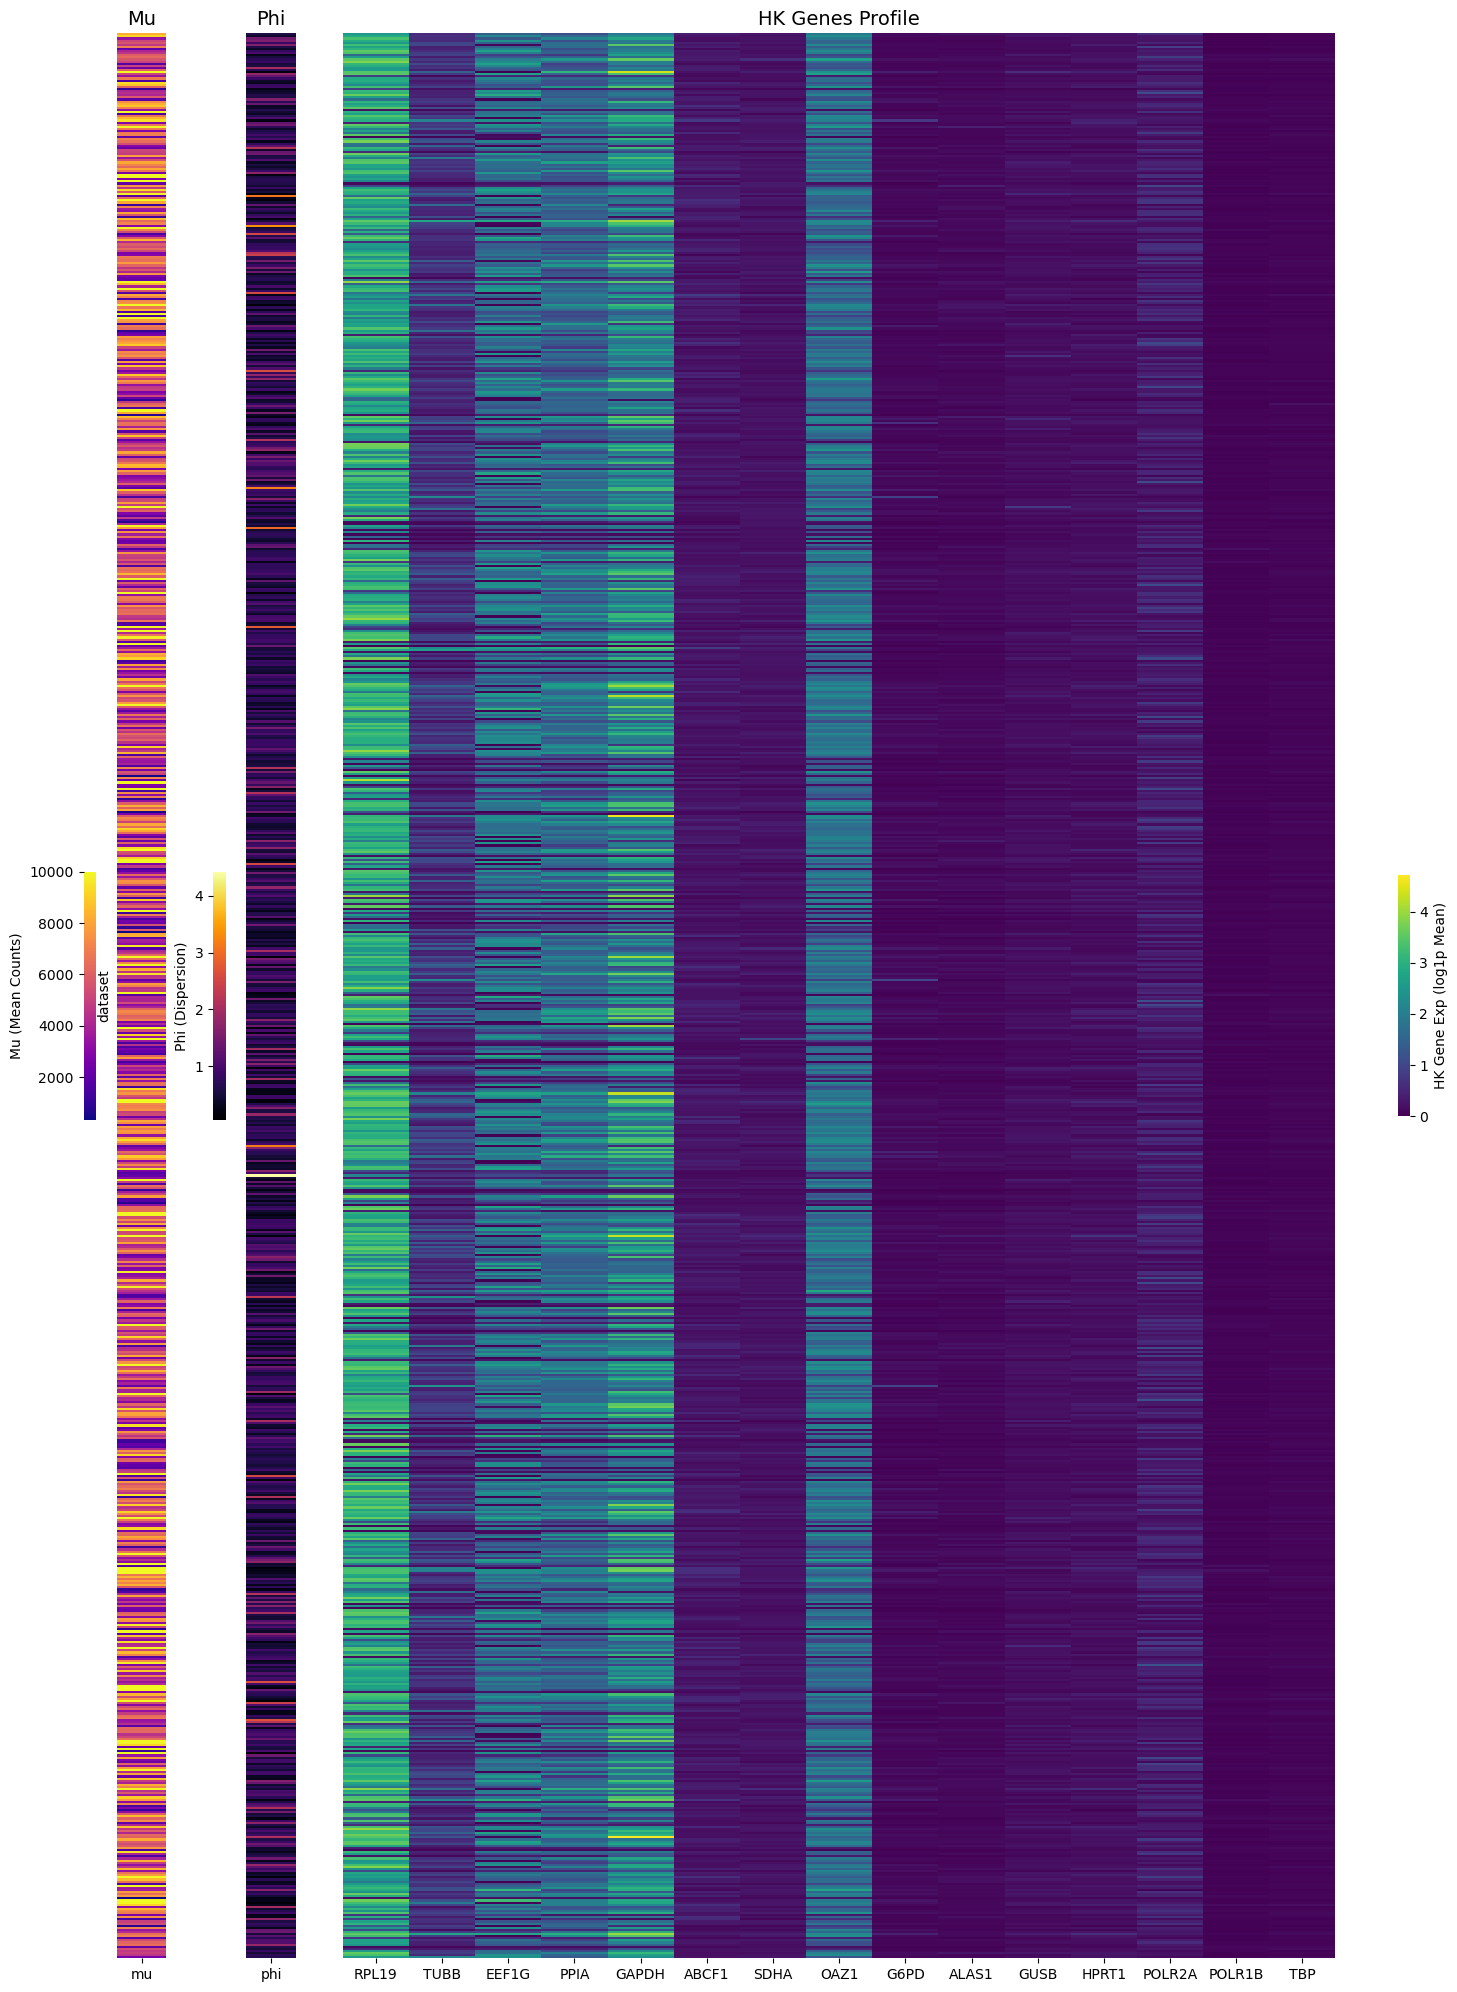

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('datasets_stats.csv')
df.set_index('dataset', inplace=True)

df['mu'] = df['mu'].clip(upper=10000)

hk_cols = [c for c in df.columns if c not in ['mu', 'phi']]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 25), 
                               gridspec_kw={'width_ratios': [1, 1, len(hk_cols)]})

sns.heatmap(df[['mu']], ax=ax1, cmap='plasma', 
            cbar_kws={'label': 'Mu (Mean Counts)', 'location': 'left', 'pad': 0.25},
            annot=False, 
            yticklabels=False)
ax1.set_title('Mu', fontsize=14)

sns.heatmap(df[['phi']], ax=ax2, cmap='inferno',
            cbar_kws={'label': 'Phi (Dispersion)', 'location': 'left', 'pad': 0.25},
            annot=False, 
            yticklabels=False)
ax2.set_title('Phi', fontsize=14)
ax2.set_ylabel('') 

sns.heatmap(df[hk_cols], ax=ax3, cmap='viridis', 
            cbar_kws={'label': 'HK Gene Exp (log1p Mean)', 'shrink': 0.125},
            annot=False, 
            yticklabels=False)
ax3.set_title('HK Genes Profile', fontsize=14)
ax3.set_ylabel('')

plt.subplots_adjust(left=0.15, wspace=0.1) 

output_file = 'datasets_heatmap.png'
plt.savefig(output_file, dpi=500, bbox_inches='tight')
print(f"Heatmap saved as '{output_file}'.")